[결론]
- portfolio 문제 없음
- profile age 118 결측치 제거("gender", "age", "income"이 모두 동일)
- transcript 모든 컬럼이 동일한 중복 데이터 397개 제거(전부 offer_completed)


In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
import warnings
import platform
import matplotlib.pyplot as plt

# 출력 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
# ============================================================
# 1. 원본 데이터 로드
# ============================================================
df_portfolio = pd.read_csv("data/portfolio.csv", index_col=0)
df_profile = pd.read_csv("data/profile.csv", index_col=0)
df_transcript = pd.read_csv("data/transcript.csv", index_col=0)
df_menu = pd.read_csv("data/starbucks_menu_260112.csv", index_col=0, encoding="cp949")

In [ ]:
# ============================================================
# 2. 데이터 기본 구조 확인
# ============================================================
print("===== 기본 크기 확인 =====")
print("\n[portfolio]")
print("shape :", df_portfolio.shape)
display(df_portfolio.head())
print()

print("[profile]")
print("shape :", df_profile.shape)
display(df_profile.head())
print()

print("[transcript]")
print("shape :", df_transcript.shape)
display(df_transcript.head())
print()

print("[menu]")
print("shape :", df_menu.shape)
display(df_menu.head())
print()


===== 기본 크기 확인 =====

[portfolio]
shape : (10, 6)


,reward,channels,difficulty,duration,offer_type,id
0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,5,"['web', 'email', 'mobile']",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,"['web', 'email']",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7



[profile]
shape : (17000, 5)


,gender,age,id,became_member_on,income
0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN



[transcript]
shape : (306534, 4)


,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0



[menu]
shape : (195, 12)


,제품코드,제품명,1회 제공량(kcal),포화지방(g),단백질(g),지방(g),트랜스지방(g),나트륨(mg),당류(g),카페인(mg),콜레스테롤(mg),탄수화물(g)
Column1,,,,,,,,,,,,
0,9.200000e+12,나이트로 바닐라 크림,80,2,1,2.7,0,40,10,232,5,10
1,9.200000e+12,나이트로 콜드 브루,5,0,0,0,0,5,0,245,0,0
2,9.200000e+12,돌체 콜드 브루,220,6,6,10,0,80,22,155,20,24
3,9.200000e+12,리저브 나이트로,5,0,0,0,0,0,0,190,0,0
4,9.200000e+12,리저브 콜드 브루,5,0,0,0,0,0,0,190,0,0


In [4]:
print(df_portfolio.isna().sum())

reward        0
channels      0
difficulty    0
duration      0
offer_type    0
id            0
dtype: int64


In [5]:
print(df_profile.isna().sum())

gender              2175
age                    0
id                     0
became_member_on       0
income              2175
dtype: int64


In [9]:
df_profile[df_profile["gender"].isna()][["gender", "age", "income"]]

,gender,age,income
0,NaN,118,NaN
2,NaN,118,NaN
4,NaN,118,NaN
6,NaN,118,NaN
7,NaN,118,NaN
...,...,...,...
16980,NaN,118,NaN
16982,NaN,118,NaN
16989,NaN,118,NaN
16991,NaN,118,NaN


In [10]:
missing_bundle = df_profile[
    df_profile["gender"].isna() &
    (df_profile["age"] == 118) &
    df_profile["income"].isna()
]

count_missing_bundle = len(missing_bundle)
count_total = len(df_profile)
ratio = count_missing_bundle / count_total * 100

print("결측치 묶음 개수:", count_missing_bundle)
print("전체 행 개수:", count_total)
print(f"전체 대비 비율: {ratio:.2f}%")

결측치 묶음 개수: 2175
전체 행 개수: 17000
전체 대비 비율: 12.79%


In [28]:
# ============================================================
# 2. 완전 중복 행 확인
# ============================================================
dup_mask = df_profile.duplicated(keep=False)   # 중복인 행 전체 표시
dup_rows = df_profile[dup_mask].sort_values(list(df_profile.columns))

dup_count = df_profile.duplicated().sum()      # 첫 행 제외, '추가 중복' 개수
dup_total_ratio = dup_count / len(df_profile) * 100

print("="*60)
print("완전 중복 행 확인")
print(f"완전 중복 행 개수(첫 행 제외): {dup_count}")
print(f"전체 대비 비율: {dup_total_ratio:.2f}%")
print("="*60)

display(dup_rows.head(20))

완전 중복 행 확인
완전 중복 행 개수(첫 행 제외): 0
전체 대비 비율: 0.00%


,gender,age,id,became_member_on,income


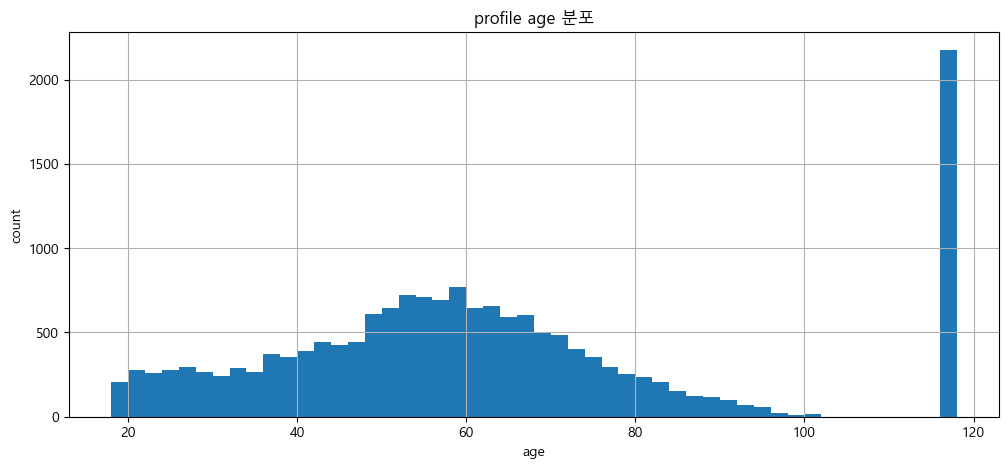

In [29]:
plt.figure(figsize=(12, 5))
df_profile["age"].hist(bins=50)
plt.title("profile age 분포")
plt.xlabel("age")
plt.ylabel("count")
plt.show()

"gender", "age", "income"이 모두 동일한 데이터는 결측치+이상치로 판단되며 제거 필요

In [6]:
print(df_transcript.isna().sum())

person    0
event     0
value     0
time      0
dtype: int64


In [7]:
print(df_menu.isna().sum())

제품코드            0
제품명             0
1회 제공량(kcal)    0
포화지방(g)         0
단백질(g)          0
지방(g)           0
트랜스지방(g)        0
나트륨(mg)         0
당류(g)           0
카페인(mg)         0
콜레스테롤(mg)       0
탄수화물(g)         0
dtype: int64


[df_transcript] feat juseoung
- offer completed 중복 로그 제거 여부 검토
- value 파싱 컬럼(offer_id, amount, reward_value)을 기준으로 분석 테이블 정리

In [33]:
import ast

completed = df_transcript[df_transcript["event"] == "offer completed"].copy()
completed.head()

# ------------------------------------------------------------
# value 컬럼을 안전하게 dict로 변환
# ------------------------------------------------------------
def parse_value(x):
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return {}
    return {}

# value를 먼저 dict 형태로 통일
df_transcript["value"] = df_transcript["value"].apply(parse_value)

# ------------------------------------------------------------
# value 파싱 함수
# ------------------------------------------------------------
def get_offer_id(x):
    if isinstance(x, dict):
        return x.get("offer id", x.get("offer_id"))
    return None

def get_amount(x):
    if isinstance(x, dict):
        return x.get("amount")
    return None

def get_reward_value(x):
    if isinstance(x, dict):
        return x.get("reward")
    return None

# 파싱 컬럼 생성
df_transcript["offer_id"] = df_transcript["value"].apply(get_offer_id)
df_transcript["amount"] = df_transcript["value"].apply(get_amount)
df_transcript["reward_value"] = df_transcript["value"].apply(get_reward_value)

# 확인
display(df_transcript[["event", "value", "offer_id", "amount", "reward_value"]].head(10))

,event,value,offer_id,amount,reward_value
0,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN
1,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN
2,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},2906b810c7d4411798c6938adc9daaa5,NaN,NaN
3,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN
4,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN
5,offer received,{'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'},f19421c1d4aa40978ebb69ca19b0e20d,NaN,NaN
6,offer received,{'offer id': '2298d6c36e964ae4a3e7e9706d1fb8c2'},2298d6c36e964ae4a3e7e9706d1fb8c2,NaN,NaN
7,offer received,{'offer id': '3f207df678b143eea3cee63160fa8bed'},3f207df678b143eea3cee63160fa8bed,NaN,NaN
8,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN
9,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN


In [34]:
print(df_transcript[["offer_id", "amount", "reward_value"]].isna().sum())

offer_id        138953
amount          167581
reward_value    272955
dtype: int64


In [14]:
completed = df_transcript[df_transcript["event"] == "offer completed"].copy()

completed.duplicated(subset=["person", "time", "offer_id", "reward_value"]).sum()

np.int64(2962)

In [16]:
completed_dup = completed[completed.duplicated(
    subset=["person", "time", "offer_id", "reward_value"],
    keep=False
)].sort_values(["person", "time", "offer_id"])

completed_dup.head(20)

,person,event,value,time,offer_id,amount,reward_value
258980,0011e0d4e6b944f998e987f904e8c1e5,offer completed,{'offer_id': '0b1e1539f2cc45b7b9fa7c272da2e1d7...,576,None,None,None
258981,0011e0d4e6b944f998e987f904e8c1e5,offer completed,{'offer_id': '9b98b8c7a33c4b65b9aebfe6a799e6d9...,576,None,None,None
218936,0020c2b971eb4e9188eac86d93036a77,offer completed,{'offer_id': 'fafdcd668e3743c1bb461111dcafc2a4...,510,None,None,None
218937,0020c2b971eb4e9188eac86d93036a77,offer completed,{'offer_id': '4d5c57ea9a6940dd891ad53e9dbe8da0...,510,None,None,None
281776,00ae03011f9f49b8a4b3e6d416678b0b,offer completed,{'offer_id': 'ae264e3637204a6fb9bb56bc8210ddfd...,618,None,None,None
281777,00ae03011f9f49b8a4b3e6d416678b0b,offer completed,{'offer_id': '2298d6c36e964ae4a3e7e9706d1fb8c2...,618,None,None,None
263988,00c2f812f4604c8893152a5c6572030e,offer completed,{'offer_id': '2906b810c7d4411798c6938adc9daaa5...,582,None,None,None
263989,00c2f812f4604c8893152a5c6572030e,offer completed,{'offer_id': '4d5c57ea9a6940dd891ad53e9dbe8da0...,582,None,None,None
242916,00cf1bbec83f4a658f8994e556db4633,offer completed,{'offer_id': 'fafdcd668e3743c1bb461111dcafc2a4...,564,None,None,None
242917,00cf1bbec83f4a658f8994e556db4633,offer completed,{'offer_id': '2906b810c7d4411798c6938adc9daaa5...,564,None,None,None


[df_portfolio 중복 확인]

In [17]:
df_profile[df_profile.duplicated(keep=False)].sort_values(by=list(df_profile.columns))

,gender,age,id,became_member_on,income


In [18]:
df_profile["id"].duplicated().sum()

np.int64(0)

In [19]:
# 1. transcript 전체 완전 중복 확인
dup_count = df_transcript.duplicated().sum()
print("완전 동일한 중복 행 수:", dup_count)

완전 동일한 중복 행 수: 397


In [20]:
df_transcript[df_transcript.duplicated(keep=False)].sort_values(by=list(df_transcript.columns))

,person,event,value,time,offer_id,amount,reward_value
218058,00d7c95f793a4212af44e632fdc1e431,offer completed,{'offer_id': '2906b810c7d4411798c6938adc9daaa5...,504,None,None,None
218060,00d7c95f793a4212af44e632fdc1e431,offer completed,{'offer_id': '2906b810c7d4411798c6938adc9daaa5...,504,None,None,None
220133,01925607d99c460996c281f17cdbb9e2,offer completed,{'offer_id': '4d5c57ea9a6940dd891ad53e9dbe8da0...,510,None,None,None
220134,01925607d99c460996c281f17cdbb9e2,offer completed,{'offer_id': '4d5c57ea9a6940dd891ad53e9dbe8da0...,510,None,None,None
171646,01956670cf414b309675aa73368b94a9,offer completed,{'offer_id': '2906b810c7d4411798c6938adc9daaa5...,420,None,None,None
...,...,...,...,...,...,...,...
274288,ff6a080134fc44dc9c7e7b5abcfbe849,offer completed,{'offer_id': 'ae264e3637204a6fb9bb56bc8210ddfd...,600,None,None,None
228665,ff80a43ecb34439491bd9ae1cff7c5fc,offer completed,{'offer_id': 'fafdcd668e3743c1bb461111dcafc2a4...,528,None,None,None
228666,ff80a43ecb34439491bd9ae1cff7c5fc,offer completed,{'offer_id': 'fafdcd668e3743c1bb461111dcafc2a4...,528,None,None,None
140993,ff95e0a9cdfd4030958762dadcb11e1a,offer completed,{'offer_id': '0b1e1539f2cc45b7b9fa7c272da2e1d7...,372,None,None,None


In [21]:
dup_rows = df_transcript[df_transcript.duplicated(keep=False)].copy()
dup_rows.groupby("event").size()

event
offer completed    793
dtype: int64

In [23]:
dup_rows = df_transcript[df_transcript.duplicated(keep=False)].copy()

vc = dup_rows.value_counts(dropna=False)
print(vc.value_counts().sort_index())

count
2    395
3      1
Name: count, dtype: int64


In [24]:
vc = df_transcript.value_counts(dropna=False)
triple_dup = vc[vc == 3]
print(triple_dup)

person                            event            value                                                          time  offer_id  amount  reward_value
3526938fb466470190a504a751ec07b0  offer completed  {'offer_id': '0b1e1539f2cc45b7b9fa7c272da2e1d7', 'reward': 5}  510   NaN       NaN     NaN             3
Name: count, dtype: int64


In [25]:
triple_row = triple_dup.index[0]
display(df_transcript[(df_transcript == pd.Series(triple_row, index=df_transcript.columns)).all(axis=1)])

,person,event,value,time,offer_id,amount,reward_value


In [27]:
dup_count = df_transcript.duplicated().sum()
remove_ratio = dup_count / len(df_transcript) * 100
print(f"중복 제거 비율: {remove_ratio:.2f}%")

중복 제거 비율: 0.13%


[clean_data]

In [35]:
# ============================================================
# 2. profile 전처리
# - gender 결측 + age=118 + income 결측 행 제거
# ============================================================
profile_invalid_mask = (
    df_profile["gender"].isna() &
    (df_profile["age"] == 118) &
    df_profile["income"].isna()
)

df_profile_cleaned = df_profile.loc[~profile_invalid_mask].copy()

print("="*60)
print("profile 전처리 완료")
print(f"제거된 행 수: {profile_invalid_mask.sum()}")
print(f"최종 행 수: {len(df_profile_cleaned)}")
print("="*60)

profile 전처리 완료
제거된 행 수: 2175
최종 행 수: 14825


In [37]:
# ============================================================
# 3. transcript 전처리
# - value(dict) 컬럼 제외하고 완전 중복 제거
# ============================================================
before_rows = len(df_transcript)

dedup_cols = [col for col in df_transcript.columns if col != "value"]

df_transcript_cleaned = df_transcript.drop_duplicates(subset=dedup_cols).copy()

after_rows = len(df_transcript_cleaned)
removed_rows = before_rows - after_rows

print("="*60)
print("transcript 전처리 완료")
print(f"제거된 중복 행 수: {removed_rows}")
print(f"최종 행 수: {after_rows}")
print("="*60)

transcript 전처리 완료
제거된 중복 행 수: 397
최종 행 수: 306137


In [38]:
# ============================================================
# 4. clean_data 폴더에 저장
# - LSB 하위 폴더에 clean_data가 이미 있다고 가정
# ============================================================
df_profile_cleaned.to_csv("clean_data/profile_cleaned.csv", encoding="utf-8-sig")
df_transcript_cleaned.to_csv("clean_data/transcript_cleaned.csv", encoding="utf-8-sig")

print("="*60)
print("전처리 파일 저장 완료")
print("저장 파일:")
print("- clean_data/profile_cleaned.csv")
print("- clean_data/transcript_cleaned.csv")
print("="*60)

전처리 파일 저장 완료
저장 파일:
- clean_data/profile_cleaned.csv
- clean_data/transcript_cleaned.csv
